# Chapter 3: Your First Neural Network on the MNIST Dataset

*Deep Learning Crash Course - BPB Publications*

We use the MNIST dataset of handwritten digits to walk through the full lifecycle of a supervised learning project: load, explore, preprocess, split, build, train, evaluate and save the model. We do this twice — first in TensorFlow / Keras and then in PyTorch — so you can see how the same pipeline maps onto each framework.


## 1. Setup

In [1]:
import os
# CPU-mode guard: hide the GPU from TensorFlow before it is imported.
# Many machines have an NVIDIA driver but a missing CUDA toolkit
# (no `ptxas`), in which case TF's XLA JIT crashes the kernel. Remove
# these two lines once you have a complete CUDA install.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = Path('images'); IMG_DIR.mkdir(exist_ok=True)

def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed)
    try:
        import tensorflow as tf; tf.random.set_seed(seed)
    except ModuleNotFoundError: pass
    try:
        import torch; torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    except ModuleNotFoundError: pass
set_seed(42)


## 2. Load and explore MNIST

Keras downloads MNIST in NumPy form. If you only have PyTorch, the `torchvision.datasets` version is shown later.

In [2]:
import tensorflow as tf
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f'Training images: {X_train_full.shape}, labels: {y_train_full.shape}')
print(f'Test images:     {X_test.shape}, labels: {y_test.shape}')
print(f'Pixel range: [{X_train_full.min()}, {X_train_full.max()}], dtype {X_train_full.dtype}')

# Class balance
labels, counts = np.unique(y_train_full, return_counts=True)
print('Per-class counts:', dict(zip(labels.tolist(), counts.tolist())))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28), labels: (60000,)
Test images:     (10000, 28, 28), labels: (10000,)
Pixel range: [0, 255], dtype uint8
Per-class counts: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


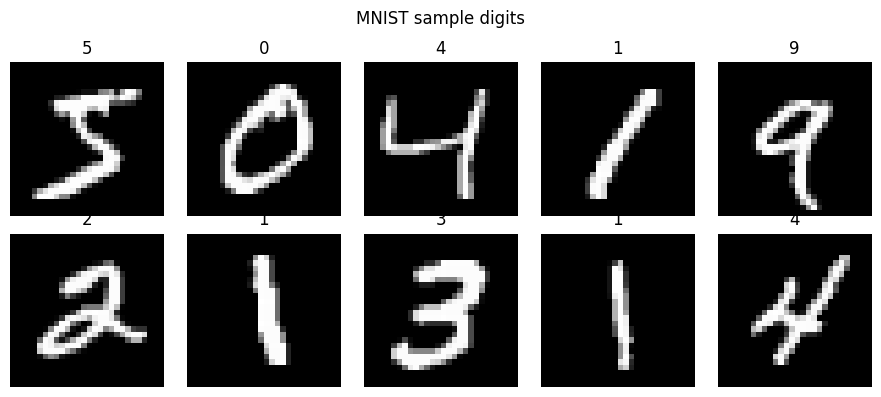

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for ax, img, lab in zip(axes.flat, X_train_full[:10], y_train_full[:10]):
    ax.imshow(img, cmap='gray'); ax.set_title(str(lab)); ax.axis('off')
fig.suptitle('MNIST sample digits')
fig.tight_layout(); fig.savefig(IMG_DIR / '01_mnist_samples.png', dpi=150); plt.show()


## 3. Preprocess: normalise, flatten, encode

Scaling pixels to `[0, 1]`, flattening 28x28 to a 784-vector, and one-hot encoding the labels for use with categorical cross-entropy.

In [4]:
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train_full = X_train_full.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)
y_train_full_oh = tf.keras.utils.to_categorical(y_train_full, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print('Flattened train shape:', X_train_full.shape, 'one-hot label shape:', y_train_full_oh.shape)


Flattened train shape: (60000, 784) one-hot label shape: (60000, 10)


## 4. Train / validation / test split

Keras gives us 60k training + 10k test. We carve a further 6k validation set out of the training set.

In [5]:
VAL_SIZE = 6000
idx = np.random.permutation(len(X_train_full))
val_idx, train_idx = idx[:VAL_SIZE], idx[VAL_SIZE:]
X_train, y_train_oh = X_train_full[train_idx], y_train_full_oh[train_idx]
X_val, y_val_oh = X_train_full[val_idx], y_train_full_oh[val_idx]
y_train = y_train_full[train_idx]; y_val = y_train_full[val_idx]
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')


Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)


## 5. Build and train a Keras model

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


2026-05-16 18:15:48.541937: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-5),
]
history = model.fit(X_train, y_train_oh,
                    validation_data=(X_val, y_val_oh),
                    epochs=15, batch_size=128, callbacks=callbacks, verbose=2)


Epoch 1/15
422/422 - 3s - 8ms/step - accuracy: 0.8838 - loss: 0.3995 - val_accuracy: 0.9500 - val_loss: 0.1708 - learning_rate: 0.0010
Epoch 2/15
422/422 - 2s - 5ms/step - accuracy: 0.9474 - loss: 0.1768 - val_accuracy: 0.9633 - val_loss: 0.1188 - learning_rate: 0.0010
Epoch 3/15
422/422 - 2s - 5ms/step - accuracy: 0.9590 - loss: 0.1325 - val_accuracy: 0.9687 - val_loss: 0.1012 - learning_rate: 0.0010
Epoch 4/15
422/422 - 2s - 5ms/step - accuracy: 0.9676 - loss: 0.1089 - val_accuracy: 0.9738 - val_loss: 0.0887 - learning_rate: 0.0010
Epoch 5/15
422/422 - 2s - 5ms/step - accuracy: 0.9719 - loss: 0.0907 - val_accuracy: 0.9745 - val_loss: 0.0867 - learning_rate: 0.0010
Epoch 6/15
422/422 - 2s - 5ms/step - accuracy: 0.9746 - loss: 0.0809 - val_accuracy: 0.9757 - val_loss: 0.0786 - learning_rate: 0.0010
Epoch 7/15
422/422 - 2s - 4ms/step - accuracy: 0.9772 - loss: 0.0705 - val_accuracy: 0.9783 - val_loss: 0.0760 - learning_rate: 0.0010
Epoch 8/15
422/422 - 2s - 4ms/step - accuracy: 0.9803 -

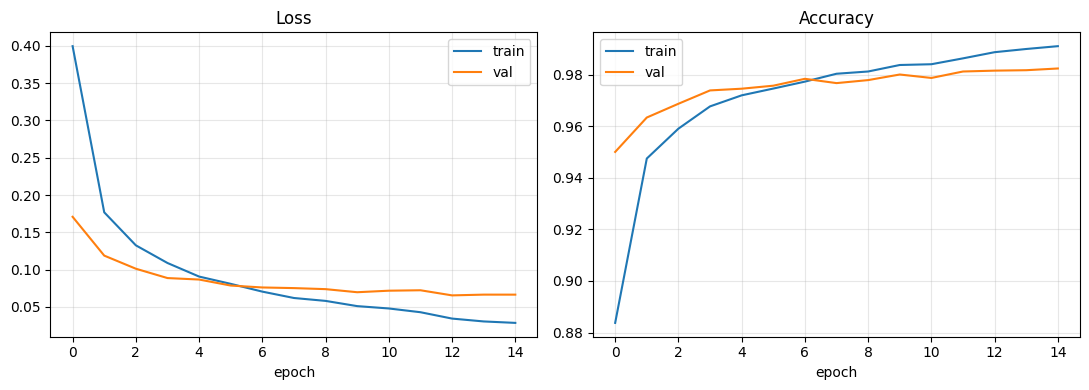

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(IMG_DIR / '02_keras_curves.png', dpi=150); plt.show()


## 6. Evaluate: accuracy, confusion matrix, misclassified examples

Test accuracy: 0.9795
              precision    recall  f1-score   support

           0     0.9798    0.9898    0.9848       980
           1     0.9895    0.9921    0.9908      1135
           2     0.9768    0.9806    0.9787      1032
           3     0.9783    0.9812    0.9797      1010
           4     0.9797    0.9817    0.9807       982
           5     0.9648    0.9821    0.9733       892
           6     0.9852    0.9749    0.9801       958
           7     0.9739    0.9815    0.9777      1028
           8     0.9863    0.9610    0.9735       974
           9     0.9790    0.9683    0.9736      1009

    accuracy                         0.9795     10000
   macro avg     0.9793    0.9793    0.9793     10000
weighted avg     0.9795    0.9795    0.9795     10000



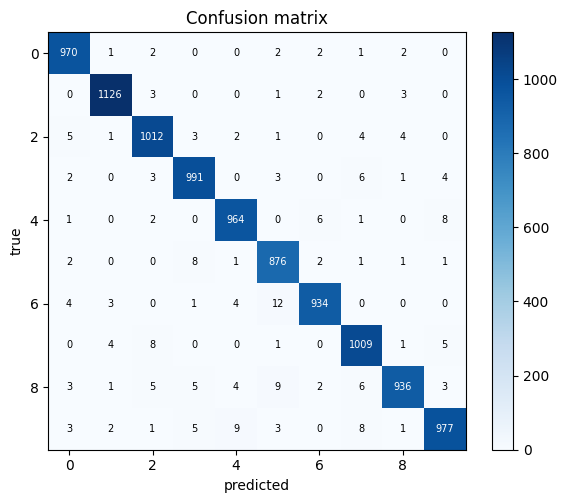

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7, color='black' if cm[i, j] < cm.max()/2 else 'white')
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('Confusion matrix')
fig.colorbar(im, ax=ax)
fig.tight_layout(); fig.savefig(IMG_DIR / '03_confusion_matrix.png', dpi=150); plt.show()


Total misclassified: 205


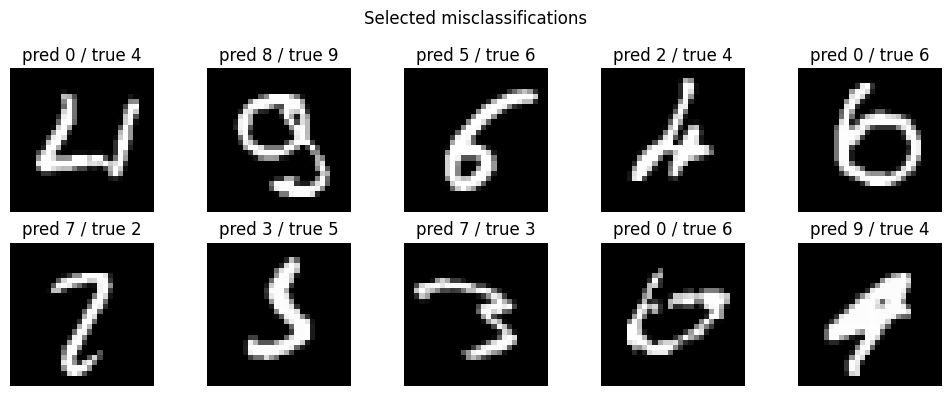

In [10]:
wrong = np.where(y_pred != y_test)[0]
print('Total misclassified:', len(wrong))
sample = wrong[:10]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, i in zip(axes.flat, sample):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'pred {y_pred[i]} / true {y_test[i]}'); ax.axis('off')
fig.suptitle('Selected misclassifications')
fig.tight_layout(); fig.savefig(IMG_DIR / '04_misclassified.png', dpi=150); plt.show()


## 7. PyTorch equivalent

Same architecture, written from scratch in PyTorch — note we output raw logits and let `CrossEntropyLoss` apply softmax internally for numerical stability.

In [11]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    set_seed(42)

    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train).long())
    val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val).long())
    test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test).long())
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=256)
    test_loader  = DataLoader(test_ds, batch_size=256)

    class TorchMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc = nn.Sequential(
                nn.Linear(784, 128), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(128, 64), nn.ReLU(),
                nn.Linear(64, 10))
        def forward(self, x): return self.fc(x)

    net = TorchMLP().to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    history_t = {'train': [], 'val': []}
    for epoch in range(8):
        net.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(net(xb), yb)
            loss.backward(); opt.step()
            running += loss.item() * xb.size(0)
        running /= len(train_loader.dataset)
        net.eval()
        v_correct = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                v_correct += (net(xb).argmax(1) == yb).sum().item()
        v_acc = v_correct / len(val_loader.dataset)
        history_t['train'].append(running); history_t['val'].append(v_acc)
        print(f'Epoch {epoch+1:2d} | train loss {running:.4f} | val acc {v_acc:.4f}')
    # final test
    net.eval(); correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (net(xb).argmax(1) == yb).sum().item()
    print(f'Test accuracy: {correct / len(test_loader.dataset):.4f}')
except ModuleNotFoundError:
    print('PyTorch not installed - skipping PyTorch section.')


Epoch  1 | train loss 0.4737 | val acc 0.9387
Epoch  2 | train loss 0.2053 | val acc 0.9547
Epoch  3 | train loss 0.1521 | val acc 0.9653
Epoch  4 | train loss 0.1228 | val acc 0.9695
Epoch  5 | train loss 0.1042 | val acc 0.9738
Epoch  6 | train loss 0.0861 | val acc 0.9773
Epoch  7 | train loss 0.0782 | val acc 0.9763
Epoch  8 | train loss 0.0684 | val acc 0.9788
Test accuracy: 0.9746


## 8. Save and reload the model

In [12]:
model.save('mnist_keras.keras')
loaded = tf.keras.models.load_model('mnist_keras.keras')
print('Reloaded model test accuracy:', loaded.evaluate(X_test, y_test_oh, verbose=0)[1])

try:
    torch.save(net.state_dict(), 'mnist_torch.pt')
    loaded_net = TorchMLP().to(device)
    loaded_net.load_state_dict(torch.load('mnist_torch.pt'))
    loaded_net.eval()
    print('Reloaded PyTorch state_dict OK.')
except NameError:
    pass


Reloaded model test accuracy: 0.9794999957084656
Reloaded PyTorch state_dict OK.


## 9. Exercise solutions

### 9.1 MCQ answer key

| Q | Answer | Why |
|---|--------|-----|
| 1 | (c) 70,000 | 60k train + 10k test. |
| 2 | (c) Stable gradients and faster convergence | Scaling to [0,1] keeps activations and gradients well-behaved. |
| 3 | (b) Validation set | Test set is reserved for final reporting. |
| 4 | (b) 100,480 | $784 \times 128 + 128$ bias terms. |
| 5 | (c) Softmax | Produces a probability distribution summing to 1. |
| 6 | (b) Overfitting | Train loss falling while val loss rises is the textbook signature. |
| 7 | (b) `CrossEntropyLoss` applies softmax internally | More numerically stable than computing softmax then log. |
| 8 | (b) Correctly classified samples per class | Off-diagonal entries are errors. |
| 9 | (b) `net.eval()` | Disables dropout and switches BatchNorm to running stats. |
| 10 | (c) Loss explodes or becomes NaN | Adam's effective LR is much larger than 0.1 implies. |
| 11 | (c) `torch.save(model.state_dict())` | Recommended portable serialisation. |
| 12 | (b) Number of epochs to wait before reducing | `patience` is the patience window. |


### 9.2 Why normalisation accelerates training
Without normalisation, the input range `[0, 255]` produces large pre-activations: $Wx$ with random $W$ and large $x$ saturates sigmoid/tanh and pushes ReLU into very large regions. The first-layer gradient $\partial L / \partial W \propto x$ scales with the input, so for un-normalised data the optimal learning rate is smaller by a factor of $\sim 255$. Scaling to `[0, 1]` keeps activations and gradients close to unit scale and lets a standard learning rate (e.g. $10^{-3}$ with Adam) converge in a handful of epochs.

In [13]:
# Confirm with a small experiment: train the same network on raw vs normalised inputs
def train_quick(X_tr, X_va, y_tr_oh, y_va_oh, epochs=3, lr=1e-3, label=''):
    set_seed(0)
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_tr, y_tr_oh, validation_data=(X_va, y_va_oh), epochs=epochs, batch_size=128, verbose=0)
    print(f'{label:20s} val acc after {epochs} epochs: {h.history["val_accuracy"][-1]:.4f}')
    return h

h_raw  = train_quick((X_train * 255).astype('float32'), (X_val * 255).astype('float32'),
                     y_train_oh, y_val_oh, label='raw [0,255]')
h_norm = train_quick(X_train, X_val, y_train_oh, y_val_oh, label='normalised [0,1]')


raw [0,255]          val acc after 3 epochs: 0.9293
normalised [0,1]     val acc after 3 epochs: 0.9655


### 9.3 99.2% train vs 95.8% test - over-fitting playbook
The 3.4 pp gap is classic over-fitting. Four interventions in order of impact:
1. **More aggressive regularisation** - increase dropout to 0.4-0.5 in the wide layer and add weight decay (`tf.keras.regularizers.l2(1e-4)`).
2. **Data augmentation** - random shifts of +/-2 pixels, +/-10 degree rotations and small zooms turn 60k MNIST examples into many millions.
3. **Early stopping** - restore the weights from the epoch with lowest val loss.
4. **Smaller model** - if the train accuracy keeps climbing toward 100 % while val stalls, the model has more capacity than the data supports.


### 9.4 One iteration of the PyTorch training loop
- `opt.zero_grad()` - PyTorch accumulates gradients into `param.grad` by default, so each step must reset them; otherwise the next backward pass adds to the previous gradient.
- `loss.backward()` - walks the computation graph backwards from `loss` and computes $\partial L / \partial \theta$ for every leaf tensor that has `requires_grad=True`. Writes the result into `param.grad`.
- `opt.step()` - applies the optimiser's update rule (e.g. Adam's bias-corrected moments) using the gradients stored on each parameter, and writes the new values back in-place.

### 9.5 Controlled batch-size experiment
Hold these constant: optimiser, LR schedule, weights initialisation, data split, number of epochs, augmentation, hardware.
Vary: batch size only (32 vs 256).
Measure: best validation accuracy across 15 epochs, repeated for at least 3 seeds, report mean and standard error. To keep the comparison fair when batch size changes, you should either keep the LR fixed (smaller batch dominates by noise) or use the linear-scaling rule (`lr = base_lr * batch_size / 256`).

In [14]:
def experiment(batch_size, epochs=5, lr=1e-3, seeds=(0, 1, 2)):
    accs = []
    for s in seeds:
        set_seed(s)
        m = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(784,)),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(10, activation='softmax'),
        ])
        m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
        h = m.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh),
                  epochs=epochs, batch_size=batch_size, verbose=0)
        accs.append(max(h.history['val_accuracy']))
    return float(np.mean(accs)), float(np.std(accs))

for bs in (32, 256):
    mu, sd = experiment(bs, epochs=3)  # 3 epochs to keep it quick; bump to 15 for real comparison
    print(f'batch={bs:4d} val acc {mu:.4f} +/- {sd:.4f}')


batch=  32 val acc 0.9740 +/- 0.0009
batch= 256 val acc 0.9604 +/- 0.0006


### 9.6 Investigating a weak class (digit 8)
1. **Inspect the confusion matrix** to see what other digit class 8 is most often confused with.
2. **Look at misclassified 8s** to spot systematic mistakes (e.g. ambiguous loops mistaken for 0 or 9).
3. **Per-class metrics**: precision, recall, F1 for class 8 - low recall + high precision = many 8s misclassified as something else.
4. **Targeted augmentation**: rotational + thickness jitter only on the 8 class.
5. **Class-weighted loss**: `class_weight={8: 1.5, ...}` to up-weight the rare class.


### 9.7 One-hot vs sparse integer labels
- **One-hot encoding** (`y_oh.shape = (N, K)`) pairs with `categorical_crossentropy`. Wastes memory at very large `K` but plays nicely with label smoothing and multi-label problems.
- **Sparse integer labels** (`y.shape = (N,)`) pair with `sparse_categorical_crossentropy` in Keras and `nn.CrossEntropyLoss` in PyTorch. Cheaper, the default choice for single-label classification with hundreds of classes.
Output layer is the same in both cases — `K` logits — only the loss changes.

### 9.8 Why `net.eval()` matters
Two layer families behave differently in train vs eval mode:
- **Dropout** is identity in eval mode but randomly zeroes activations in train mode.
- **BatchNorm** uses *batch statistics* during training and the accumulated *running statistics* during eval. Forgetting `net.eval()` means each validation batch's accuracy depends on the other items in that batch.
If you forget the call, dropout fires during validation and the network produces a noisy, downward-biased accuracy. Reported numbers can easily look 1-3 pp lower than the true value, with most of the noise concentrated in small batches.

---
*End of Chapter 3.*
